In [29]:
import torch
t_version = str(torch.__version__)
s_src = f"https://pytorch-geometric.com/whl/torch-{t_version}.html"
sp_src = f"https://pytorch-geometric.com/whl/torch-{t_version}.html"
!pip install torch-scatter -f $s_src
!pip install torch-sparse -f $sp_src
!pip install torch-geometric
!pip install -q git+https://github.com/snap-stanford/deepsnap.git

Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html


  ERROR: Error [WinError 2] The system cannot find the file specified while executing command git clone -q https://github.com/snap-stanford/deepsnap.git 'C:\Users\SRMAPCSELAB2022-346\AppData\Local\Temp\pip-req-build-3tp834v0'
ERROR: Cannot find command 'git' - do you have 'git' installed and in your PATH?


In [30]:
import torch_geometric
torch_geometric.__version__

'2.6.1'

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from tqdm import trange
from torch_geometric.utils import add_self_loops, softmax
from sklearn.metrics import roc_auc_score, average_precision_score
from torch_scatter import scatter
from torch_geometric.utils import degree  

class GraphNNStack(nn.Module):
    def __init__(self, input_features, hidden_features, output_features, configuration, return_embeddings=True):
        super(GraphNNStack, self).__init__()

        assert configuration.model_type == 'GraphContrastiveLearning'

        self.num_layers = min(configuration.num_layers, 5)
        self.dropout = configuration.dropout
        self.return_embeddings = return_embeddings

        self.convs = nn.ModuleList()

        self.convs.append(GraphContrastiveLearning(input_features, hidden_features, dropout=self.dropout))

        for _ in range(self.num_layers - 1):
            self.convs.append(GraphContrastiveLearning(hidden_features, hidden_features, dropout=self.dropout))
            
    def select_conv_layer(self, conv_type):
        if conv_type == 'GraphContrastiveLearning':
            return GraphContrastiveLearning
        else:
            raise ValueError(f"Unknown model type: {conv_type}")         

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)

            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)

        return x
    
       

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

In [32]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree, softmax
from torch.nn import Parameter


class GraphContrastiveLearning(MessagePassing):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super(GraphContrastiveLearning, self).__init__(aggr='mean')

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.dropout = dropout

        # Encoder (GNN layer)
        self.lin = nn.Linear(in_channels, out_channels)

        # Projection head (important for contrastive learning)
        self.projection_head = nn.Sequential(
            nn.Linear(out_channels, out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels)
        )

        self.reset_parameters()

    def reset_parameters(self):
        self.lin.reset_parameters()
        for layer in self.projection_head:
            if hasattr(layer, 'reset_parameters'):
                layer.reset_parameters()

    def forward(self, x, edge_index):
        # Add self-loops
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        # Linear transform
        x = self.lin(x)

        # Message passing
        x = self.propagate(edge_index, x=x)

        # Activation
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Projection
        z = self.projection_head(x)

        return z

    def message(self, x_j):
        return x_j

    def aggregate(self, inputs, index, dim_size=None):
        return scatter(inputs, index, dim=0, dim_size=dim_size, reduce='mean')

    def contrastive_loss(self, z1, z2, temperature=0.5):
        z1 = F.normalize(z1, dim=-1)
        z2 = F.normalize(z2, dim=-1)

        sim_matrix = torch.mm(z1, z2.t()) / temperature

        exp_sim = torch.exp(sim_matrix)
        loss = -torch.log(exp_sim.diag() / (exp_sim.sum(dim=1) + 1e-8)).mean()

        return loss

In [33]:
import torch.optim as optim
def setup_optimizer_and_scheduler(configuration, model_params):
    weight_decay = configuration.weight_decay
    trainable_params = filter(lambda p: p.requires_grad, model_params)

    if configuration.optimizer == 'adam':
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)
    elif configuration.optimizer == 'sgd':
        optimizer = torch.optim.SGD(trainable_params, lr=configuration.learning_rate, momentum=0.95, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)

    return None, optimizer

In [34]:
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from torch_geometric.data import HeteroData, Data
import zipfile
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
from torch_geometric.data import Data
import torch
import torch.nn.functional as F


def download_and_extract_amazonbook():
    """
    Extract AmazonBook dataset from uploaded ZIP file
    and return the actual dataset directory.
    """

    print("Extracting AmazonBook dataset...")

    zip_file = "amazon-book.zip"

    extract_path = "amazonbook"

    # Create extraction directory
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)

    # Extract ZIP
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset extracted successfully!")

    print(f"Files extracted to: {extract_path}")

    print("\nDirectory structure:")

    for root, dirs, files in os.walk(extract_path):

        level = root.replace(
            extract_path,
            ''
        ).count(os.sep)

        indent = ' ' * 2 * level

        print(
            f"{indent}"
            f"{os.path.basename(root)}/"
        )

        subindent = ' ' * 2 * (level + 1)

        for file in files[:10]:

            print(
                f"{subindent}"
                f"{file}"
            )

   

    dataset_folder = os.path.join(
        extract_path,
        "amazon-book"
    )

    if os.path.exists(dataset_folder):

        print(
            "\nAmazonBook dataset folder found:"
        )

        print(dataset_folder)

        print("\nDataset files:")

        for file in os.listdir(dataset_folder):

            print(f"  - {file}")

        return dataset_folder

    # Fallback
    print(
        "\nWarning:"
        " amazon-book folder not found."
    )

    return extract_path



def load_amazonbook_heterogeneous(data_path):
        

    print(
        f"Loading AmazonBook dataset "
        f"from: {data_path}"
    )

    data = HeteroData()

   

    user_file = os.path.join(
        data_path,
        "user_list.txt"
    )

    user_df = pd.read_csv(
        user_file,
        sep=' ',
        skiprows=1,
        names=['org_id', 'remap_id']
    )

    num_users = len(user_df)

   

    item_file = os.path.join(
        data_path,
        "item_list.txt"
    )

    item_df = pd.read_csv(
        item_file,
        sep=' ',
        skiprows=1,
        names=['org_id', 'remap_id']
    )

    num_books = len(item_df)

    print(
        f"Users : {num_users}"
    )

    print(
        f"Books : {num_books}"
    )

   

    data['user'].x = torch.ones(
        (num_users, 1),
        dtype=torch.float
    )

    data['book'].x = torch.ones(
        (num_books, 1),
        dtype=torch.float
    )

    data['user'].num_nodes = num_users
    data['book'].num_nodes = num_books

    # ==================================================
    # TRAIN EDGES
    # ==================================================

    edge_list = []

    train_file = os.path.join(
        data_path,
        "train.txt"
    )

    with open(
        train_file,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            tokens = line.strip().split()

            if len(tokens) < 2:
                continue

            user = int(tokens[0])

            items = [
                int(x)
                for x in tokens[1:]
            ]

            for item in items:

                edge_list.append(
                    [user, item]
                )

    edge_index = torch.tensor(
        edge_list,
        dtype=torch.long
    ).t().contiguous()

    data[
        'user',
        'interacts',
        'book'
    ].edge_index = edge_index

    data[
        'user',
        'interacts',
        'book'
    ].original_edge_index = (
        edge_index.clone()
    )

   

    test_edges = []

    test_file = os.path.join(
        data_path,
        "test.txt"
    )

    with open(
        test_file,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            tokens = line.strip().split()

            if len(tokens) < 2:
                continue

            user = int(tokens[0])

            items = [
                int(x)
                for x in tokens[1:]
            ]

            for item in items:

                test_edges.append(
                    [user, item]
                )

    test_edge_index = torch.tensor(
        test_edges,
        dtype=torch.long
    ).t().contiguous()

    data[
        'user',
        'interacts',
        'book'
    ].test_edge_index = (
        test_edge_index
    )

    print("\nFINAL STATISTICS")

    print(
        f"Users: "
        f"{num_users}"
    )

    print(
        f"Books: "
        f"{num_books}"
    )

    print(
        f"Training edges: "
        f"{edge_index.shape[1]}"
    )

    print(
        f"Testing edges: "
        f"{test_edge_index.shape[1]}"
    )

    return data




def convert_amazonbook_to_homogeneous(data):
    """Convert AmazonBook heterogeneous graph to homogeneous graph"""

    print("Converting AmazonBook to homogeneous graph...")

    num_users = data['user'].num_nodes
    num_books = data['book'].num_nodes

    total_nodes = num_users + num_books

    edge_indices = []

    

    if ('user', 'interacts', 'book') in data.edge_types:

        user_book = data[
            'user',
            'interacts',
            'book'
        ].edge_index

        # -----------------------------------------------
        # user -> book
        # -----------------------------------------------

        user_book_adj = user_book.clone()

        user_book_adj[1] += num_users

       

        book_user = torch.stack(
            [
                user_book[1],
                user_book[0]
            ],
            dim=0
        )

        book_user[0] += num_users

        edge_indices.append(
            user_book_adj
        )

        edge_indices.append(
            book_user
        )

   

    if len(edge_indices) > 0:

        edge_index = torch.cat(
            edge_indices,
            dim=1
        )

        edge_index = torch.unique(
            edge_index,
            dim=1
        )

        print(
            f"Created "
            f"{edge_index.shape[1]} "
            f"edges"
        )

    else:

        edge_index = torch.empty(
            (2, 0),
            dtype=torch.long
        )

        print(
            "Warning: No edges found!"
        )

   

    user_features = data[
        'user'
    ].x.float()

    book_features = data[
        'book'
    ].x.float()

    max_dim = max(
        user_features.shape[1],
        book_features.shape[1]
    )

    if user_features.shape[1] < max_dim:

        user_features = F.pad(
            user_features,
            (
                0,
                max_dim -
                user_features.shape[1]
            )
        )

    if book_features.shape[1] < max_dim:

        book_features = F.pad(
            book_features,
            (
                0,
                max_dim -
                book_features.shape[1]
            )
        )

    x = torch.cat(
        [
            user_features,
            book_features
        ],
        dim=0
    )

   

    original_edges = data[
        'user',
        'interacts',
        'book'
    ].edge_index.clone()
    
    test_edges = data[
    'user',
    'interacts',
    'book'
    ].test_edge_index.clone()

    print(
        f"Stored original "
        f"user-book edges: "
        f"{original_edges.shape[1]}"
    )

    

    homogeneous_data = Data(
         x=x,
        edge_index=edge_index,
        num_nodes=total_nodes,
        num_users=num_users,
        num_books=num_books,
        original_user_book_edges=original_edges,
        test_user_book_edges=test_edges
    )

    print(
        f"Homogeneous graph created "
        f"with {total_nodes} nodes"
    )

    return homogeneous_data

def print_dataset_details(homogeneous_data):
    """Print dataset details for AmazonBook"""

    print("\n" + "=" * 60)

    print("Dataset name: AmazonBook")

    print(f"Total nodes: {homogeneous_data.num_nodes}")

    print(
        f"Total edges: "
        f"{homogeneous_data.edge_index.shape[1]}"
    )

    print(
        f"Number of user nodes: "
        f"{homogeneous_data.num_users}"
    )

    print(
        f"Number of book nodes: "
        f"{homogeneous_data.num_books}"
    )

    print(
        f"Feature dimension: "
        f"{homogeneous_data.x.shape[1]}"
    )

    print("=" * 60)
    
    
def prepare_link_prediction_data(homogeneous_data):

    print("\n" + "=" * 60)
    print("Preparing AmazonBook link prediction data...")
    print("=" * 60)

    num_users = homogeneous_data.num_users
    

    # =====================================================
    # Positive edges
    # =====================================================

    if (not hasattr(
            homogeneous_data,
            "original_user_book_edges")
        or
        homogeneous_data.original_user_book_edges is None):

        raise ValueError(
            "No original user-book edges found!"
        )

    train_pos_edge_index = (
    homogeneous_data
    .original_user_book_edges
    .clone()
    )

    train_pos_edge_index[1] += num_users

    test_pos_edge_index = (
    homogeneous_data
    .test_user_book_edges
    .clone()
    )

    test_pos_edge_index[1] += num_users

    '''print(
        f"Positive edges: "
        f"{pos_edge_index.shape[1]}"
    ) '''
    
    print(
    f"Training Positive edges: "
    f"{train_pos_edge_index.shape[1]}"
    )

    print(
    f"Testing Positive edges: "
    f"{test_pos_edge_index.shape[1]}"
    )

       
    homogeneous_data.train_pos_edge_index = train_pos_edge_index

          
    num_users = homogeneous_data.num_users
    num_books = homogeneous_data.num_books

    num_neg_samples = test_pos_edge_index.size(1)

    
    
    neg_users = torch.randint(
        0,
        num_users,
        (num_neg_samples,)
    )

    neg_books = torch.randint(
        num_users,
        num_users + num_books,
        (num_neg_samples,)
    )

    test_neg_edge_index = torch.stack(
        [
            neg_users,
            neg_books
        ],
        dim=0
    )
    
    test_pos_label = torch.ones(
        test_pos_edge_index.size(1)
    )

    test_neg_label = torch.zeros(
        test_neg_edge_index.size(1)
    )

    homogeneous_data.test_edge_index = torch.cat(
        [
            test_pos_edge_index,
            test_neg_edge_index
        ],
        dim=1
    )

    homogeneous_data.test_edge_label = torch.cat(
        [
            test_pos_label,
            test_neg_label
        ]
    )
    
   
    print("\nDataset Statistics")

    print(
        f"Train edges: "
        f"{train_pos_edge_index.shape[1]}"
    )

    print(
        f"Test positive edges: "
        f"{test_pos_edge_index.shape[1]}"
    )

    print(
        f"Test negative edges: "
        f"{test_neg_edge_index.shape[1]}"
    )

    return homogeneous_data


def train_link_prediction_model(data, configuration):

    model = GraphNNStack(
        data.num_node_features,
        configuration.hidden_dim,
        configuration.hidden_dim,
        configuration,
        return_embeddings=True
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=configuration.learning_rate,
        weight_decay=configuration.weight_decay
    )

    losses = []
    
    
    
    for epoch in trange(
            configuration.epochs,
            desc="Link Prediction Training"):

        model.train()
        optimizer.zero_grad()

        z = model(data)

        pos_edge_index = data.train_pos_edge_index

        if pos_edge_index.size(1) == 0:
            print("No positive edges!")
            break

        

        max_train_edges = min(
            200000,
            pos_edge_index.size(1)
        )

        perm = torch.randperm(
            pos_edge_index.size(1)
        )[:max_train_edges]

        pos_edge_batch = pos_edge_index[:, perm]
        
                      
        neg_users = pos_edge_batch[0]

        neg_books = torch.randint(
            data.num_users,
            data.num_users + data.num_books,
            (max_train_edges,),
            device=pos_edge_batch.device
        )

        neg_edge_index = torch.stack(
            [neg_users, neg_books],
            dim=0
        )
        
        pos_pred = model.decode(
            z,
            pos_edge_batch
        )

        neg_pred = model.decode(
            z,
            neg_edge_index
        )

        pos_loss = -torch.log(
            torch.sigmoid(pos_pred) + 1e-15
        ).mean()

        neg_loss = -torch.log(
            1 - torch.sigmoid(neg_pred) + 1e-15
        ).mean()

        loss = pos_loss + neg_loss

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    # ==================================================
    # Final Evaluation
    # ==================================================

    model.eval()

    with torch.no_grad():

        z = model(data)

        test_size = min(
            50000,
            data.test_edge_index.size(1)
        )

        idx = torch.randperm(
            data.test_edge_index.size(1)
        )[:test_size]

        test_edges = (
            data.test_edge_index[:, idx]
        )

        test_labels = (
            data.test_edge_label[idx]
        )

        test_pred = torch.sigmoid(
            model.decode(
                z,
                test_edges
            )
        )

        test_auc = roc_auc_score(
            test_labels.cpu().numpy(),
            test_pred.cpu().numpy()
        )

        test_ap = average_precision_score(
            test_labels.cpu().numpy(),
            test_pred.cpu().numpy()
        )

        test_binary = (
            test_pred > 0.5
        ).float()

        test_accuracy = (
            (test_binary == test_labels)
            .float()
            .mean()
            .item()
        )

        test_precision = precision_score(
            test_labels.cpu().numpy(),
            test_binary.cpu().numpy(),
            zero_division=0
        )

        test_recall = recall_score(
            test_labels.cpu().numpy(),
            test_binary.cpu().numpy(),
            zero_division=0
        )

        test_f1 = f1_score(
            test_labels.cpu().numpy(),
            test_binary.cpu().numpy(),
            zero_division=0
        )

    test_metrics = {
        'accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'auc': test_auc,
        'ap': test_ap
    }

    return (
        losses,
        model,
        test_metrics
    )

def evaluate_recommendation(
        model,
        data,
        k_list=[5, 10, 20]):

    model.eval()

    HR = {k: [] for k in k_list}
    NDCG = {k: [] for k in k_list}
    MRR = []

    with torch.no_grad():

        z = model(data)

        pos_edges = data.test_edge_index[
            :,
            data.test_edge_label == 1
        ]

        if pos_edges.shape[1] == 0:

            print(
                "No positive test edges!"
            )

            return {
                f'HR@{k}': 0
                for k in k_list
            }

        # ======================================
        # AmazonBook is huge
        # evaluate only subset
        # ======================================

        max_eval_edges = min(
            10000,
            pos_edges.shape[1]
        )

        eval_idx = torch.randperm(
            pos_edges.shape[1]
        )[:max_eval_edges]

        pos_edges = pos_edges[:, eval_idx]
        
        all_books = set(
                range(
                    data.num_users,
                    data.num_users +
                    data.num_books
                )
            )

        for edge in pos_edges.t():

            user = edge[0].item()

            pos_book = edge[1].item()

            # ==================================
            # All books
            # ==================================

            

            # ==================================
            # Books already seen
            # ==================================

            user_seen = set(
                data.train_pos_edge_index[1][
                    data.train_pos_edge_index[0]
                    == user
                ].cpu().numpy()
            )

            candidate_books = list(
                all_books - user_seen
            )

            if len(candidate_books) < 99:
                continue

            neg_books = np.random.choice(
                candidate_books,
                99,
                replace=False
            )

            candidates = (
                list(neg_books)
                + [pos_book]
            )

            users = torch.full(
                (len(candidates),),
                user,
                dtype=torch.long
            )

            books = torch.tensor(
                candidates,
                dtype=torch.long
            )

            edge_index = torch.stack(
                [users, books]
            )

            scores = model.decode(
                z,
                edge_index
            ).cpu().numpy()

            ranking = np.argsort(
                scores
            )[::-1]

            ranked_books = [
                candidates[i]
                for i in ranking
            ]

            for k in k_list:

                if pos_book in ranked_books[:k]:

                    HR[k].append(1)

                    rank = (
                        ranked_books.index(
                            pos_book
                        ) + 1
                    )

                    NDCG[k].append(
                        1 /
                        np.log2(rank + 1)
                    )

                else:

                    HR[k].append(0)

                    NDCG[k].append(0)

            rank = (
                ranked_books.index(
                    pos_book
                ) + 1
            )

            MRR.append(
                1 / rank
            )

    results = {}

    for k in k_list:

        results[f'HR@{k}'] = (
            np.mean(HR[k])
            if HR[k]
            else 0
        )

        results[f'NDCG@{k}'] = (
            np.mean(NDCG[k])
            if NDCG[k]
            else 0
        )

    results['MRR'] = (
        np.mean(MRR)
        if MRR
        else 0
    )

    return results

class Config:
    def __init__(self, parameters):
        self.__dict__.update(parameters)


STEP 1: Loading AmazonBook Dataset
Extracting AmazonBook dataset...
Dataset extracted successfully!
Files extracted to: amazonbook

Directory structure:
amazonbook/
  amazon-book/
    item_list.txt
    README.md
    test.txt
    train.txt
    user_list.txt

AmazonBook dataset folder found:
amazonbook\amazon-book

Dataset files:
  - item_list.txt
  - README.md
  - test.txt
  - train.txt
  - user_list.txt
Loading AmazonBook dataset from: amazonbook\amazon-book
Users : 52643
Books : 91599

FINAL STATISTICS
Users: 52643
Books: 91599
Training edges: 2380730
Testing edges: 603378

STEP 2: Converting to Homogeneous Graph
Converting AmazonBook to homogeneous graph...
Created 4761460 edges
Stored original user-book edges: 2380730
Homogeneous graph created with 144242 nodes

Dataset name: AmazonBook
Total nodes: 144242
Total edges: 4761460
Number of user nodes: 52643
Number of book nodes: 91599
Feature dimension: 1

STEP 3: Preparing Data for Link Prediction

Preparing AmazonBook link predictio

Link Prediction Training: 100%|██████████████████████████████████████████████████████| 300/300 [06:22<00:00,  1.27s/it]



FINAL RESULTS
Model: GraphContrastiveLearning
Dataset: AmazonBook (Link Prediction)

--- LINK PREDICTION METRICS ---
AUC:       0.4839
AP:        0.4977

--- RECOMMENDATION METRICS ---
HR@5:   0.0418
HR@10:  0.1186
HR@20:  0.2966
NDCG@5:  0.0240
NDCG@10: 0.0486
NDCG@20: 0.0929
MRR:     0.0551

Time Taken: 383.04 seconds


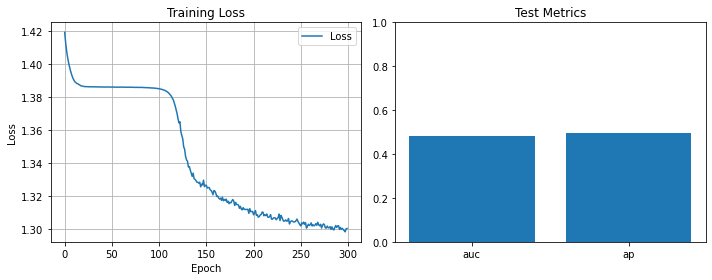

In [35]:
def main_link_prediction():
    configurations = [
        {
            'model_type':'GraphContrastiveLearning',
            'dataset': 'AmazonBook',
            'num_layers': 2,
            'heads': 1,
            'hidden_dim': 64,
            'dropout': 0.4,
            'epochs': 300,
            'weight_decay': 1e-4,
            'learning_rate': 0.001
        },
    ]

    for config_dict in configurations:
        config = Config(config_dict)
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
       
      
        print("\n" + "="*60)
        print("STEP 1: Loading AmazonBook Dataset")
        print("="*60)
        data_path = download_and_extract_amazonbook()
       
        heterogeneous_data = load_amazonbook_heterogeneous(data_path)
        
               
        print("\n" + "="*60)
        print("STEP 2: Converting to Homogeneous Graph")
        print("="*60)
        homogeneous_data = convert_amazonbook_to_homogeneous(heterogeneous_data)
        homogeneous_data = homogeneous_data.to(device)  # Move to device
        print_dataset_details(homogeneous_data)
        
        print("\n" + "="*60)
        print("STEP 3: Preparing Data for Link Prediction")
        print("="*60)
        homogeneous_data = prepare_link_prediction_data(homogeneous_data)

        print("\n" + "="*60)
        print(f"STEP 4: Training {config.model_type} for LINK PREDICTION")
        print("="*60)

        start_time = time.time()
        #val_aucs, losses, best_model, test_metrics = train_link_prediction_model(homogeneous_data, config)
        losses, best_model, test_metrics = train_link_prediction_model(homogeneous_data,config)
        end_time = time.time()
        elapsed_time = end_time - start_time

        print("\n" + "="*60)
        print("FINAL RESULTS")
        print("="*60)
        print(f"Model: {config.model_type}")
        print(f"Dataset: {config.dataset} (Link Prediction)")
        
        print("\n--- LINK PREDICTION METRICS ---")
        print(f"AUC:       {test_metrics['auc']:.4f}")
        print(f"AP:        {test_metrics['ap']:.4f}")
        
        
        print("\n--- RECOMMENDATION METRICS ---")
        rec_metrics = evaluate_recommendation(best_model, homogeneous_data)
        if rec_metrics:  
            print(f"HR@5:   {rec_metrics['HR@5']:.4f}")
            print(f"HR@10:  {rec_metrics['HR@10']:.4f}")
            print(f"HR@20:  {rec_metrics['HR@20']:.4f}")
            print(f"NDCG@5:  {rec_metrics['NDCG@5']:.4f}")
            print(f"NDCG@10: {rec_metrics['NDCG@10']:.4f}")
            print(f"NDCG@20: {rec_metrics['NDCG@20']:.4f}")
            print(f"MRR:     {rec_metrics['MRR']:.4f}")
        
        print(f"\nTime Taken: {elapsed_time:.2f} seconds")
        print("="*60)

        # Plot results
        plt.figure(figsize=(10, 4))
        
        plt.subplot(1, 2, 1)
        plt.title(f"Training Loss")
        plt.plot(losses, label="Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        
        plt.subplot(1, 2, 2)
        
        
       
        metrics_to_plot = ['auc', 'ap']
        values = [test_metrics[m] for m in metrics_to_plot]
        plt.bar(metrics_to_plot, values)
        plt.title("Test Metrics")
        plt.ylim(0, 1)
        
        
        plt.tight_layout()
        plt.show()

# ==================== RUN LINK PREDICTION ====================
if __name__ == '__main__':
    main_link_prediction()